In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_csv('../Data/processed/data_modeling.csv')
data.head()

,id_partido,Equipo_local,Goles_avg5_local,goles_rival_avg5_local,tiros_avg5_local,tiros_al_arco_avg5_local,corners_avg5_local,faltas_avg5_local,amarillas_avg5_local,rojas_avg5_local,...,faltas_avg5_visitante,amarillas_avg5_visitante,rojas_avg5_visitante,goles_ht_avg5_visitante,goles_ht_rival_avg5_visitante,resultado_avg5_visitante,B365H,B365D,B365A,FTR
0,1951,Barcelona,1.8,1.0,18.2,7.2,7.0,19.2,2.0,0.0,...,22.0,3.4,0.0,0.6,0.4,1.4,1.33,4.50,9.50,D
1,1952,Getafe,1.8,1.0,13.2,5.6,4.4,23.0,3.4,0.4,...,21.0,2.4,0.2,0.4,0.8,1.8,2.60,3.20,2.62,H
2,1953,Cadiz,0.6,1.0,7.6,3.4,6.6,16.0,2.4,0.0,...,18.0,1.4,0.0,1.2,0.4,2.4,2.50,3.20,2.75,D
3,1954,La Coruna,1.2,0.8,13.4,4.8,4.6,16.8,3.0,0.2,...,22.8,4.2,0.2,0.4,0.0,1.8,1.66,3.40,5.50,A
4,1955,Malaga,1.4,1.2,11.4,4.6,4.6,20.4,2.0,0.2,...,21.2,2.4,0.2,0.6,0.2,0.8,2.40,3.25,2.80,A


In [3]:
data.describe()

,id_partido,Goles_avg5_local,goles_rival_avg5_local,tiros_avg5_local,tiros_al_arco_avg5_local,corners_avg5_local,faltas_avg5_local,amarillas_avg5_local,rojas_avg5_local,goles_ht_avg5_local,...,corners_avg5_visitante,faltas_avg5_visitante,amarillas_avg5_visitante,rojas_avg5_visitante,goles_ht_avg5_visitante,goles_ht_rival_avg5_visitante,resultado_avg5_visitante,B365H,B365D,B365A
count,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,...,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000
mean,5880.668524,1.307658,1.348996,12.088247,4.264351,4.932539,14.560270,2.533705,0.148996,0.575664,...,5.062408,14.557393,2.509628,0.146534,0.599093,0.576571,1.410704,2.657750,3.964757,4.808795
std,2255.803781,0.659877,0.583584,2.757686,1.379623,1.394057,3.050716,0.736996,0.177713,0.388513,...,1.420659,3.061210,0.733404,0.177236,0.399863,0.355816,0.670920,2.005311,1.493206,4.318629
min,1951.000000,0.000000,0.000000,4.200000,0.600000,0.800000,5.800000,0.600000,0.000000,0.000000,...,1.000000,5.800000,0.400000,0.000000,0.000000,0.000000,0.000000,1.020000,2.500000,1.080000
25%,3933.000000,0.800000,1.000000,10.200000,3.400000,4.000000,12.400000,2.000000,0.000000,0.200000,...,4.000000,12.400000,2.000000,0.000000,0.400000,0.400000,0.800000,1.670000,3.250000,2.600000
50%,5892.000000,1.200000,1.400000,11.800000,4.000000,4.800000,14.400000,2.600000,0.200000,0.600000,...,5.000000,14.200000,2.400000,0.200000,0.600000,0.600000,1.400000,2.100000,3.400000,3.500000
75%,7836.000000,1.600000,1.800000,13.600000,5.000000,5.800000,16.400000,3.000000,0.200000,0.800000,...,6.000000,16.400000,3.000000,0.200000,0.800000,0.800000,1.800000,2.800000,4.000000,5.250000
max,9770.000000,5.400000,4.000000,24.200000,11.800000,12.000000,28.200000,5.200000,1.400000,2.800000,...,11.400000,28.800000,5.400000,1.200000,3.200000,2.400000,3.000000,26.000000,17.000000,41.000000


In [4]:
data.isnull().sum()

id_partido                       0
Equipo_local                     0
Goles_avg5_local                 0
goles_rival_avg5_local           0
tiros_avg5_local                 0
tiros_al_arco_avg5_local         0
corners_avg5_local               0
faltas_avg5_local                0
amarillas_avg5_local             0
rojas_avg5_local                 0
goles_ht_avg5_local              0
goles_ht_rival_avg5_local        0
resultado_avg5_local             0
temporada                        0
Date                             0
Equipo_visitante                 0
Goles_avg5_visitante             0
goles_rival_avg5_visitante       0
tiros_avg5_visitante             0
tiros_al_arco_avg5_visitante     0
corners_avg5_visitante           0
faltas_avg5_visitante            0
amarillas_avg5_visitante         0
rojas_avg5_visitante             0
goles_ht_avg5_visitante          0
goles_ht_rival_avg5_visitante    0
resultado_avg5_visitante         0
B365H                            0
B365D               

Teniendo en cuenta la informacion hallada de que las apuestas tienen en base un acierto del 53.5%, esta informacion la tomaremos como base de nuestro modelo, donde se buscara mejor tal porcentaje

In [5]:
x_features = \
['Goles_avg5_local',
 'goles_rival_avg5_local',
 'tiros_avg5_local',
 'tiros_al_arco_avg5_local',
 'corners_avg5_local',
 'faltas_avg5_local',
 'amarillas_avg5_local',
 'rojas_avg5_local',
 'goles_ht_avg5_local',
 'goles_ht_rival_avg5_local',
 'resultado_avg5_local',
 'Goles_avg5_visitante',
 'goles_rival_avg5_visitante',
 'tiros_avg5_visitante',
 'tiros_al_arco_avg5_visitante',
 'corners_avg5_visitante',
 'faltas_avg5_visitante',
 'amarillas_avg5_visitante',
 'rojas_avg5_visitante',
 'goles_ht_avg5_visitante',
 'goles_ht_rival_avg5_visitante',
 'resultado_avg5_visitante',
 'B365H',
 'B365D',
 'B365A']

In [6]:
temp = [2425, 2526]
train_x = data[~data['temporada'].isin(temp)][x_features]
train_y = data[~data['temporada'].isin(temp)]['FTR']
test_x = data[data['temporada']==2425][x_features]
test_y = data[data['temporada']==2425]['FTR']
validation_x = data[data['temporada']==2526][x_features]
validation_y = data[data['temporada']==2526]['FTR']

In [7]:
print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)
print(validation_x.shape, validation_y.shape)

(7072, 25) (7072,)
(380, 25) (380,)
(265, 25) (265,)


In [8]:
baseline_test = test_x[['B365H','B365A','B365D']].idxmin(axis=1,skipna=False).str[-1]

In [9]:
(baseline_test == test_y).mean()

np.float64(0.5447368421052632)

In [10]:
clf = DTC(random_state=42)
clf.fit(train_x, train_y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
y_pred = clf.predict(test_x)

accuracy = accuracy_score(test_y, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.4052631578947368


In [12]:
accuracy = accuracy_score(train_y, clf.predict(train_x))
print(f'Accuracy: {accuracy}')

Accuracy: 1.0


El modelo de arbol de decision tiene una mal % de acierto en la prueba, pero en el entrenamiento tiene un arcierto del 100%, esto indica un sobreajuste del modelo.

In [13]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [14]:
param_grid = {
    'max_depth': [1,3,5,7,9],
    'min_samples_leaf': [1,3,5,7,9],
    'min_samples_split': [2,4,6,8,10],
    'criterion': ["entropy", "gini"]
}

In [15]:
tscv = TimeSeriesSplit(n_splits=5)
gsearch = GridSearchCV(estimator=clf, cv=tscv,
                        param_grid=param_grid)

In [16]:
gsearch.fit(train_x, train_y)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [1, 3, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [17]:
y_pred = gsearch.best_estimator_.predict(test_x)

accuracy = accuracy_score(test_y, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.5605263157894737


Cuando se ajusta el modelo mejora su rendimiento, llegando a mejorar la que realiza las de las apuestas

In [18]:
from sklearn.metrics import classification_report

print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

           A       0.54      0.61      0.57       114
           D       0.00      0.00      0.00        97
           H       0.57      0.85      0.68       169

    accuracy                           0.56       380
   macro avg       0.37      0.49      0.42       380
weighted avg       0.42      0.56      0.48       380



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Aun se tiene problemas para poder predecir los partidos que terminan en empate

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
param_grid_rf = \
                {'n_estimators': [100,150],
                 'max_features': [5, 7, 9],
                 'max_depth'   : [1, 3, 10],
                 'min_samples_leaf': [1, 3, 5],
                 'min_samples_split': [2, 4, 6],
                 'criterion': ["entropy", "gini"],
                 'n_jobs': [-1]
                }

rf = RandomForestClassifier(random_state=42,n_jobs=-1)


In [21]:
gsearch_rf = GridSearchCV(estimator=rf, cv=tscv,param_grid=param_grid_rf)
gsearch_rf.fit(train_x, train_y)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['entropy', 'gini'], 'max_depth': [1, 3, ...], 'max_features': [5, 7, ...], 'min_samples_leaf': [1, 3, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [22]:
gsearch_rf.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'max_features': 9,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 150,
 'n_jobs': -1}

In [23]:
y_pred_rf = gsearch_rf.best_estimator_.predict(test_x)

accuracy_rf = accuracy_score(test_y, y_pred_rf)
print(f'Accuracy: {accuracy_rf}')

Accuracy: 0.5526315789473685


In [24]:
print(classification_report(test_y, y_pred_rf))

              precision    recall  f1-score   support

           A       0.55      0.58      0.56       114
           D       0.00      0.00      0.00        97
           H       0.55      0.85      0.67       169

    accuracy                           0.55       380
   macro avg       0.37      0.48      0.41       380
weighted avg       0.41      0.55      0.47       380



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
from lightgbm import LGBMClassifier

In [26]:
# Mapeo de labels (si no lo hiciste ya)
map_resultado = {'H': 0, 'D': 1, 'A': 2}
y_train_mapped = train_y.map(map_resultado)
y_test_mapped = test_y.map(map_resultado)


In [27]:
# Modelo base
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)

In [28]:
# Grid de hiperparámetros
param_grid_lgbm = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_samples': [5, 10, 20]
}


In [29]:
# GridSearchCV con TimeSeriesSplit
gsearch_lgbm = GridSearchCV(estimator=lgbm, param_grid=param_grid_lgbm, cv=tscv, n_jobs=-1)
gsearch_lgbm.fit(train_x, y_train_mapped)

,estimator,"LGBMClassifie...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], 'n_estimators': [100, 150, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [30]:
gsearch_lgbm.best_params_

{'learning_rate': 0.01,
 'max_depth': 3,
 'min_child_samples': 20,
 'n_estimators': 100,
 'num_leaves': 15}

In [31]:
y_pred_lgbm = gsearch_lgbm.best_estimator_.predict(test_x)

accuracy_lgbm = accuracy_score(y_test_mapped, y_pred_lgbm)
print(f'Accuracy: {accuracy_lgbm}')

Accuracy: 0.5394736842105263


In [32]:
print(classification_report(y_test_mapped, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.52      0.93      0.67       169
           1       0.00      0.00      0.00        97
           2       0.62      0.42      0.50       114

    accuracy                           0.54       380
   macro avg       0.38      0.45      0.39       380
weighted avg       0.42      0.54      0.45       380



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Los modelos se mantienen simple para evitar sobreajustarse pasaremos un parametro para penalizar los errores para ver si puede predecir algo de los empates que hasta ahora solo consigue predecir perdida y victoria

In [33]:
lgbm_balanced = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1, class_weight='balanced')

In [34]:
# GridSearchCV con TimeSeriesSplit  balanceado
gsearch_lgbm_balanced = GridSearchCV(estimator=lgbm_balanced, param_grid=param_grid_lgbm, cv=tscv, n_jobs=-1)
gsearch_lgbm_balanced.fit(train_x, y_train_mapped)

,estimator,"LGBMClassifie...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [5, 10, ...], 'n_estimators': [100, 150, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [35]:
gsearch_lgbm_balanced.best_params_

{'learning_rate': 0.01,
 'max_depth': 3,
 'min_child_samples': 20,
 'n_estimators': 100,
 'num_leaves': 15}

In [36]:
y_pred_lgbm_balance = gsearch_lgbm_balanced.best_estimator_.predict(test_x)

accuracy_lgbm_balance = accuracy_score(y_test_mapped, y_pred_lgbm_balance)
print(f'Accuracy: {accuracy_lgbm_balance}')

Accuracy: 0.5236842105263158


In [37]:
print(classification_report(y_test_mapped, y_pred_lgbm_balance))

              precision    recall  f1-score   support

           0       0.67      0.57      0.62       169
           1       0.32      0.39      0.35        97
           2       0.55      0.57      0.56       114

    accuracy                           0.52       380
   macro avg       0.51      0.51      0.51       380
weighted avg       0.54      0.52      0.53       380



In [39]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

In [41]:
param_grid_xgb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [42]:
gsearch_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1, verbosity=0),
    param_grid=param_grid_xgb, cv=tscv, n_jobs=-1
)
gsearch_xgb.fit(train_x, y_train_mapped)  # sin sample_weight

,estimator,"XGBClassifier...state=42, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [43]:
gsearch_xgb.best_estimator_

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
y_pred_xgb_ = gsearch_xgb.best_estimator_.predict(test_x)

accuracy_xgb = accuracy_score(y_test_mapped, y_pred_xgb_)
print(f'Accuracy: {accuracy_xgb}')

Accuracy: 0.5394736842105263


In [45]:
print(classification_report(y_test_mapped, y_pred_xgb_))

              precision    recall  f1-score   support

           0       0.54      0.86      0.66       169
           1       0.00      0.00      0.00        97
           2       0.54      0.53      0.53       114

    accuracy                           0.54       380
   macro avg       0.36      0.46      0.40       380
weighted avg       0.40      0.54      0.45       380



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [40]:
sample_weights = compute_sample_weight('balanced', y_train_mapped)

In [46]:
gsearch_xgb_balanced = GridSearchCV(estimator=XGBClassifier(random_state=42, n_jobs=-1, verbosity=0), param_grid=param_grid_xgb, cv=tscv, n_jobs=-1)

In [47]:
gsearch_xgb_balanced.fit(train_x, y_train_mapped, 
                          sample_weight=sample_weights)

,estimator,"XGBClassifier...state=42, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [48]:
y_pred_xgb_balanced = gsearch_xgb_balanced.best_estimator_.predict(test_x)

accuracy_xgb_balanced = accuracy_score(y_test_mapped, y_pred_xgb_balanced)
print(f'Accuracy: {accuracy_xgb_balanced}')

Accuracy: 0.5263157894736842


In [49]:
print(classification_report(y_test_mapped, y_pred_xgb_balanced))

              precision    recall  f1-score   support

           0       0.67      0.56      0.61       169
           1       0.34      0.45      0.39        97
           2       0.56      0.54      0.55       114

    accuracy                           0.53       380
   macro avg       0.52      0.52      0.52       380
weighted avg       0.55      0.53      0.54       380



## Resumen Comparativo de Modelos

| Modelo | Accuracy | Precision (H) | Recall (H) | Precision (D) | Recall (D) | Precision (A) | Recall (A) |
|---|---|---|---|---|---|---|---|
| B365 Baseline | 54.47% | 0.56 | 0.87 | 0.00 | 0.00 | 0.55 | 0.58 |
| Decision Tree (tuneado) | 56.05% | 0.57 | 0.86 | 0.00 | 0.00 | 0.55 | 0.57 |
| Random Forest (tuneado) | 55.26% | 0.55 | 0.85 | 0.00 | 0.00 | 0.55 | 0.58 |
| LightGBM | 53.95% | 0.52 | 0.93 | 0.00 | 0.00 | 0.62 | 0.42 |
| LightGBM (balanced) | 52.37% | 0.67 | 0.57 | 0.32 | 0.39 | 0.55 | 0.57 |
| Xgboost | 53.95% | 0.54 | 0.86 | 0.00 | 0.00 | 0.54 | 0.53 |
| **Xgboost (balanced)** | **52.63%** | **0.67** | **0.56** | **0.34** | **0.45** | **0.56** | **0.54** |


De todos los modelos considerados esperando mejorar la accuracy global dado por la base de la casa de apuestas (54.47%), el mejor es el arbol de desición, pero este modelo es incapaz de poder predecir bien cuando un partido termina en empate
en cambio el lightgbm y xgboost balanceados predicen los empate (lgbm balanced: 4 de cada 10 y xgboost balanced: 5 de cada 10) el cual no es capaz de ninguno (otros modelos). Por ello se considera mejor ese modelo para poder predecir el resultado del partido.
XGBoost balanced es marginalmente mejor en Draw (+6 puntos de recall) sin sacrificar mucho en H y A. Y como bien dices, la distribución de métricas entre las tres clases está más equilibrada.
Los empates muestran un desafio para los modelos incluso para los de B365 que teniendo mas informacion y mejores modelos no llegan a ser capaces de predecirlo.

el XGBoost balanced también generaliza bien en datos nuevos, o el mejorcito recall de Draw era ruido del test set, Si se mantiene o sube en validación (como pasó con LGBM que subió de 0.39 a 0.44), entonces se tiene un candidato fuerte a modelo final.

## Validacion del modelo

## LightGBM

In [50]:
map_validation_y = data[data['temporada']==2526]['FTR'].map(map_resultado)

In [51]:
y_pred_validation = gsearch_lgbm_balanced.best_estimator_.predict(validation_x)

In [52]:
accuracy_lgbm_val = accuracy_score(map_validation_y, y_pred_validation)
print(f'Accuracy: {accuracy_lgbm_val}')

Accuracy: 0.5056603773584906


In [53]:
print(classification_report(map_validation_y, y_pred_validation))

              precision    recall  f1-score   support

           0       0.71      0.50      0.59       122
           1       0.32      0.44      0.37        70
           2       0.51      0.58      0.54        73

    accuracy                           0.51       265
   macro avg       0.51      0.51      0.50       265
weighted avg       0.55      0.51      0.52       265



## XGboost

In [54]:
y_pred_validation_xgb = gsearch_xgb_balanced.best_estimator_.predict(validation_x)

In [55]:
accuracy_xgb_val = accuracy_score(map_validation_y, y_pred_validation_xgb)
print(f'Accuracy: {accuracy_xgb_val}')

Accuracy: 0.5018867924528302


In [57]:
print(classification_report(map_validation_y, y_pred_validation_xgb))

              precision    recall  f1-score   support

           0       0.72      0.52      0.60       122
           1       0.31      0.44      0.37        70
           2       0.50      0.53      0.52        73

    accuracy                           0.50       265
   macro avg       0.51      0.50      0.49       265
weighted avg       0.55      0.50      0.52       265



la clase D: el recall subió de 0.39 a 0.44 en validación. El modelo sigue prediciendo empates, y de hecho lo hace un poco mejor en datos completamente nuevos. Eso es una buena señal — significa que no fue un resultado de suerte en el test.
El accuracy bajó un poco de 52.4% a 50.6%(modelo de lightbgm balanceado) y de 52.4% a 50.2%(modelo de xgb balanceado) , pero se mantiene en el mismo rango. No hay caída drástica, lo que indica que el modelo generaliza de forma consistente — no hay overfitting.


## Conclusiones del Modelamiento

1. **Techo de accuracy:** modelos sin balanceo orbitan entre 54-56%, apenas superando el baseline de B365 (54.47%). Esto sugiere que las features actuales (rolling averages + odds) tienen un límite natural de predicción.2 algoritmos distintos (boosting con gradient descent vs boosting con histogramas) llegan al mismo techo con las mismas features. Eso refuerza que el límite está en los datos, no en el modelo.

2. **Problema estructural de los empates:** Ningún modelo sin balanceo es capaz de predecir empates (recall D = 0.00). Este es un problema conocido en el dominio — ni siquiera B365 con sus modelos sofisticados logra predecirlos.

3. **Modelo elegido — LightGBM balanced:** tiene class_weight='balanced' integrado (más limpio que sample_weight externo), entrenó más rápido, y los resultados son prácticamente idénticos.

4. **Generalización:** El modelo mantiene rendimiento consistente entre test (52.4%) y validación (50.6%), confirmando que no hay overfitting.

5. **Posibles mejoras futuras:**
   - Features dinámicas de clasificación (posición en tabla, puntos acumulados)
   - Transformación de odds a probabilidades implícitas

## Entendimiento del modelo

In [60]:
import shap

In [61]:
explainer = shap.TreeExplainer(gsearch_lgbm_balanced.best_estimator_)
shap_values = explainer.shap_values(test_x)

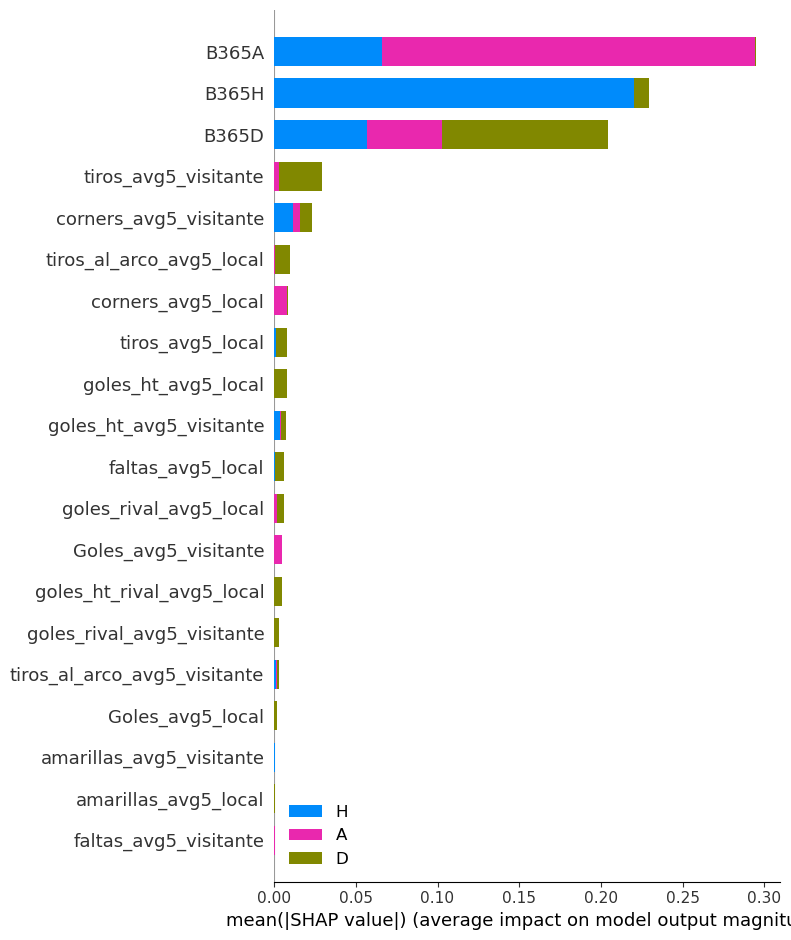

In [66]:
# General (importance bar)
shap.summary_plot(shap_values, test_x, plot_type='bar', class_names=['H','D','A'])

* Las tres odds de B365 dominan completamente la importancia del modelo. Hay una brecha enorme entre B365A/B365H/B365D y el resto de features. Las rolling averages aportan información marginal en comparación.
* B365D (la tercera barra). La porción verde oliva (D) es proporcionalmente la más grande de las tres odds — es decir, B365D es la feature que más contribuye a predecir empates. Cuando la casa de apuestas ve un partido parejo, la cuota de empate baja, y eso es la señal más fuerte que el modelo tiene para predecir Draw.
* De las rolling averages, las que más aportan son tiros_avg5_visitante y corners_avg5_visitante. Curiosamente las del visitante pesan más que las del local. Las features de amarillas, faltas del visitante y goles del local están en el fondo con importancia cercana a cero.

In [67]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(test_x.shape)

<class 'numpy.ndarray'>
380
(25, 3)
(380, 25)


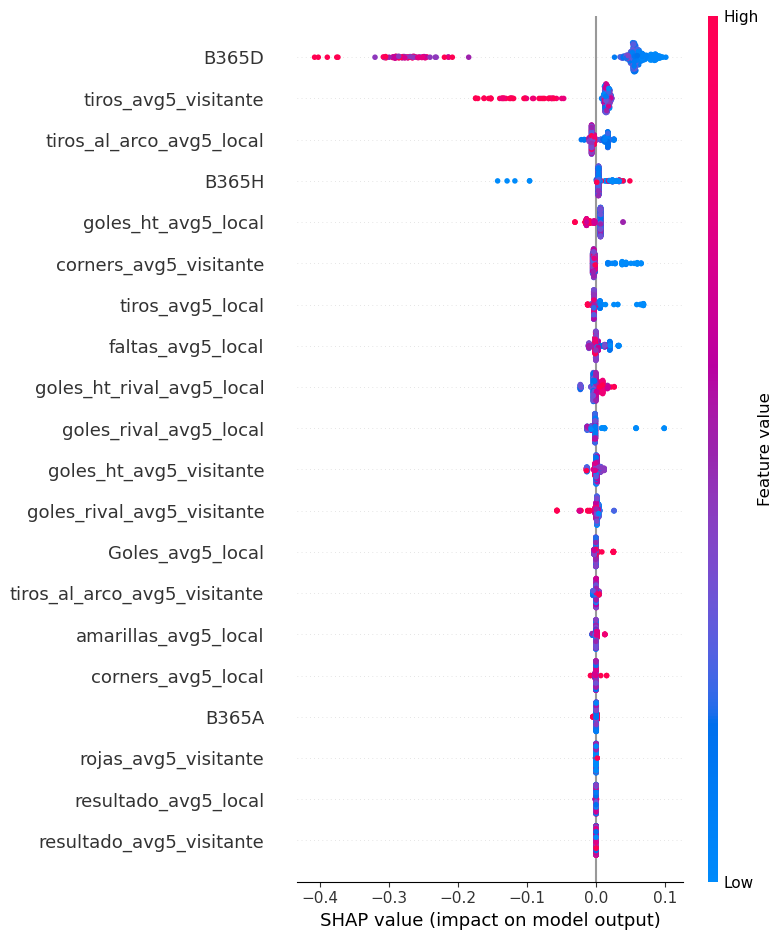

In [68]:
# Clase Draw = índice 1
shap.summary_plot(shap_values[:, :, 1], test_x, 
                  title='SHAP - Clase Draw')

* B365D es la feature dominante para Draw, y la dirección tiene sentido perfecto: los puntos rojos (valor alto de B365D = cuota alta = empate improbable según la casa) están a la izquierda (SHAP negativo = empuja lejos del Draw). Los puntos azules (valor bajo de B365D = cuota baja = empate probable) están a la derecha (SHAP positivo = empuja hacia el Draw). El modelo aprendió correctamente la lógica inversa de las cuotas.
* B365A y B365H casi no aparecen para Draw. Fíjate que B365A está casi al fondo. Esto es un insight interesante: para predecir H o A, las tres odds importan mucho (lo viste en el bar plot), pero para predecir Draw, básicamente solo importa B365D. Las odds de local y visitante no ayudan mucho a distinguir empates.
* Las rolling averages aportan poco pero con dirección. tiros_avg5_visitante es la rolling average más relevante para Draw — los puntos rojos (muchos tiros del visitante) empujan ligeramente hacia Draw. Piénsalo: un visitante que tira mucho pero no convierte podría indicar un partido parejo.


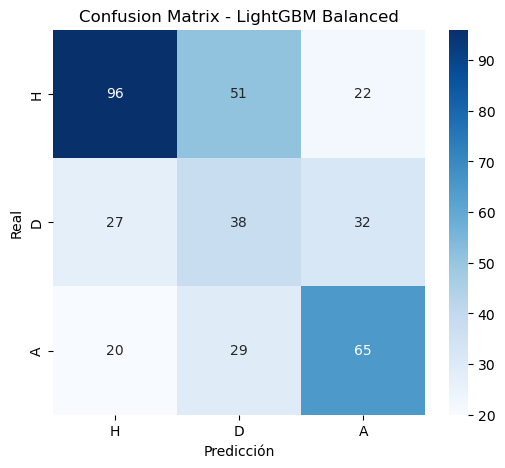

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test_mapped, y_pred_lgbm_balance)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H','D','A'], 
            yticklabels=['H','D','A'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Confusion Matrix - LightGBM Balanced')
plt.show()

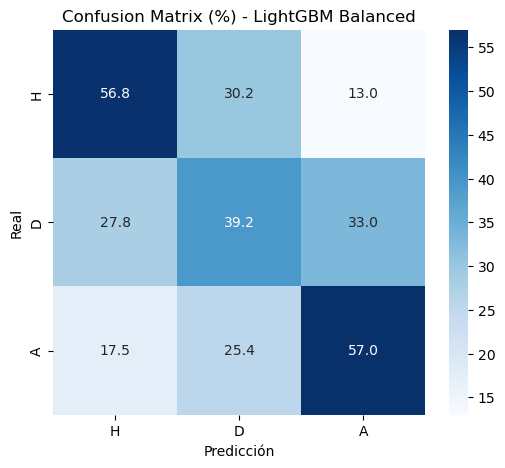

In [70]:
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(6,5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['H','D','A'], 
            yticklabels=['H','D','A'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Confusion Matrix (%) - LightGBM Balanced')
plt.show()

* **H (LOCAL):** Cuando el modelo falla en victorias locales, el 30.2% lo manda a Draw y solo 13% a Away. los partidos que parecían victoria local pero terminan en empate son los más "engañosos" para el modelo. Son partidos donde el local domina pero no convierte.

* **D (Empate):** El 60.8% de empates reales se pierde y se reparte casi parejo entre H (27.8%) y A (33.0%). Esto es clave: el modelo no tiene un sesgo direccional claro al fallar en empates. No es que "mande todo a H" — simplemente no logra distinguir empates de resultados decisivos en ninguna dirección.

* **A (Visitante):**: Patrón simétrico al de H — cuando falla, el error va más hacia D (25.4%) que hacia H (17.5%).


D tiene mucho ruido. El modelo predice Draw 118 veces (51+38+29), pero solo acierta 38. Es decir, la precision de D es baja (32%) porque muchas victorias reales (tanto H como A) se "contaminan" hacia la predicción de empate. Eso confirma que el Draw no tiene una señal clara que lo separe — está en una zona intermedia entre H y A donde las features no alcanzan para distinguirlo.

## Calibracion

In [75]:
from sklearn.calibration import calibration_curve
import numpy as np


In [73]:
# Probabilidades predichas
y_proba = gsearch_lgbm_balanced.best_estimator_.predict_proba(test_x)

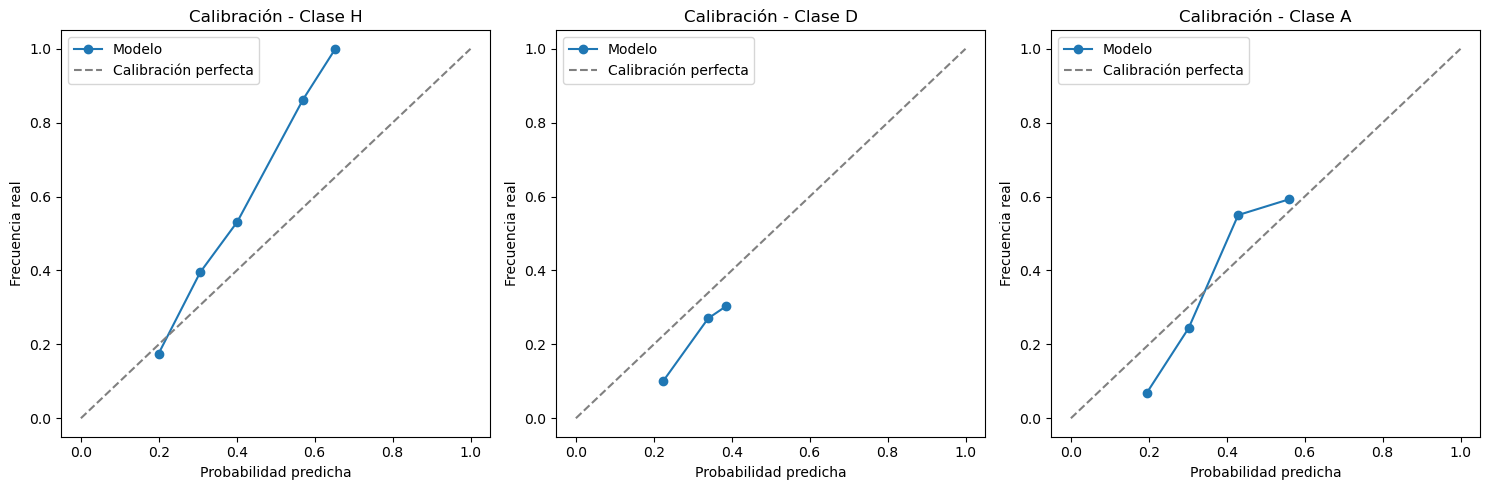

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
clases = ['H', 'D', 'A']

for i, (ax, clase) in enumerate(zip(axes, clases)):
    # Convertir a binario: clase i vs resto
    y_true_bin = (y_test_mapped == i).astype(int)
    
    prob_true, prob_pred = calibration_curve(y_true_bin, y_proba[:, i], 
                                              n_bins=8)
    
    ax.plot(prob_pred, prob_true, marker='o', label='Modelo')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Calibración perfecta')
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Frecuencia real')
    ax.set_title(f'Calibración - Clase {clase}')
    ax.legend()

plt.tight_layout()
plt.show()

* **Clase H:** La mejor calibrada de las tres. La curva sigue la diagonal de cerca — cuando el modelo dice 40% de probabilidad de victoria local, efectivamente gana el local alrededor del 40% de las veces. El modelo es confiable para H.
* **Clase D:** Dos observaciones. Primera, el rango de probabilidades es muy estrecho (el modelo nunca asigna más de ~40% a Draw). Esto confirma que el modelo nunca está "seguro" de un empate. Segunda, la curva está ligeramente por debajo de la diagonal — el modelo está levemente sobreconfiado en Draw: dice 35% pero la realidad es ~28%.
* **Clase A:** La curva está por encima de la diagonal en el rango medio. Cuando el modelo dice 30-40% de Away, la realidad es más cercana a 50-60%. El modelo subestima la probabilidad de victoria visitante — es subconfiado para A.


El modelo nunca tiene alta confianza en empates. Mientras que para H alcanza probabilidades de 65-70%, para D nunca pasa de ~40%. Esto refuerza cuantitativamente que el Draw vive en una zona de incertidumbre donde el modelo no puede comprometerse

In [76]:
max_proba = y_proba.max(axis=1)
correct = (y_pred_lgbm_balance == y_test_mapped)

# Dividir en "seguro" vs "inseguro"
umbral = np.median(max_proba)
print(f'Umbral (mediana): {umbral:.3f}')
print(f'Accuracy cuando seguro (>{umbral:.2f}): {correct[max_proba >= umbral].mean():.3f}')
print(f'Accuracy cuando inseguro (<={umbral:.2f}): {correct[max_proba < umbral].mean():.3f}')
print(f'N seguro: {(max_proba >= umbral).sum()}, N inseguro: {(max_proba < umbral).sum()}')

Umbral (mediana): 0.394
Accuracy cuando seguro (>0.39): 0.668
Accuracy cuando inseguro (<=0.39): 0.379
N seguro: 190, N inseguro: 190


* **Cuando el modelo está "seguro" (probabilidad máxima > 39%), acierta el 66.8%.**
 Eso es 12 puntos por encima del baseline B365 (54.5%). Cuando está "inseguro" (≤39%), cae a 37.9% — peor que tirar una moneda entre 3 opciones (33%).

* **El insight clave:** El modelo sabe cuándo no sabe. Las probabilidades no solo sirven para predecir la clase ganadora, sino para filtrar predicciones confiables. Si solo apostaras en partidos donde el modelo tiene confianza alta, tu accuracy sube significativamente.
* **Otro ángulo:** La mediana es 0.394 — es decir, en la mitad de los partidos, el modelo no asigna más de 39% a ninguna clase. Eso es casi un tercio por clase — básicamente aleatorio. Confirma que en la mitad de los partidos de La Liga, no hay señal suficiente para predecir el resultado.
Esto conecta directamente el "techo estructural": no es que el modelo sea malo, es que el fútbol tiene un ~50% de partidos donde el resultado es inherentemente impredecible con las features disponibles.

## Conclusiones Finales

1. **Dominio de las odds B365:** El análisis SHAP revela que las tres 
odds de B365 concentran la mayor parte de la capacidad predictiva. 
Las rolling averages aportan información marginal. Esto sugiere que 
las casas de apuestas ya incorporan implícitamente la forma reciente 
de los equipos en sus cuotas.

2. **El empate como limitación estructural:** Ningún modelo logra 
predecir empates sin balanceo de clases. Con balanceo, el recall 
de Draw alcanza ~44% en validación, pero a costa de accuracy global. 
El SHAP muestra que solo B365D tiene señal relevante para Draw — 
las rolling averages son prácticamente inútiles para esta clase. 
La confusion matrix confirma que los empates fallidos se reparten 
sin sesgo entre H y A, indicando ausencia de señal direccional.

3. **Calibración asimétrica:** El modelo está bien calibrado para 
victoria local, sobreconfiado en empates, y subconfiado en victorias 
visitantes. Nunca asigna más de ~40% de probabilidad a Draw.

4. **El modelo sabe cuándo no sabe:** Cuando la confianza es alta 
(>39%), el accuracy sube a 66.8% — 12 puntos sobre el baseline. 
Cuando es baja, cae a 37.9%. En ~50% de los partidos, el modelo 
no tiene señal suficiente para una predicción confiable.

5. **Implicación práctica:** El valor del modelo no está en superar 
el accuracy global de B365, sino en 
    - 5.1  identificar partidos donde 
la predicción es confiable.
    - 5.2 ofrecer capacidad de predicción 
de empates que los modelos convencionales ignoran.

6. **Limitaciones:** Variables no observadas (lesiones, motivación, 
decisiones tácticas, clima) contribuyen al ruido inherente del fútbol. 
Features dinámicas (posición en tabla, rachas) y la transformación de 
odds a probabilidades implícitas son mejoras pendientes.

## Exportando el mejor modelo

In [58]:
import joblib
import os

os.makedirs('../model', exist_ok=True)
joblib.dump(gsearch_lgbm_balanced.best_estimator_, '../model/lgbm_balanced.pkl')

['../model/lgbm_balanced.pkl']